In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from edtf.parser.parser_classes import Date, Interval

from data import CollectionAccessor, ImageHandler, EmbeddingSpaceAccessor

from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [2]:
def init_MKG():
    MKG_DIR = "./MKG"
    image_folder = MKG_DIR+"/images"
    image_handler = ImageHandler("MKG", image_folder=image_folder, keep_prefix=False)

    # time_stamp, pub_file, priv_file = CollectionAccessor.get_latest_dump("./data/dumps")

    time_stamp = "2025-06-05"
    mkg_meta = dict(name="Museum Kunst & Gewerbe", id_="MKG_"+time_stamp,
                    creation_timestamp=time_stamp, language="de")
    df = CollectionAccessor.get_MKG(metadata_path=MKG_DIR+"/dumps/extraction_v0_1.csv",
                                    image_handler=image_handler,
                                    **mkg_meta)

    return image_handler, df

imgs, mkg = init_MKG()

100%|███████████████████████████████████████████████████████████████████████| 26294/26294 [00:24<00:00, 1079.99it/s]


In [3]:
def time_to_num(x):
    if isinstance(x, Date):
        return int(x.year)
    if isinstance(x, Interval):
        l, u = x.lower, x.upper
        if isinstance(l, Date) and isinstance(u, Date):
            return (int(l.year) + int(u.year))/2
        try:
            return int(l.year)
        except AttributeError:
            try:
                return int(u.year)
            except AttributeError:
                return 0
    
    raise ValueError


def my_resize(image):
    fixed_w = 224
    r = image.height/image.width 
    # .thumbnail DOESN'T RETURN ANYTHING
    image.thumbnail((fixed_w, fixed_w*r))#,Image.ANTIALIAS)


def load_image(p):
    if not p:
        return Image.new(mode="RGB", size=(512,512))
    path = "./MKG/images/" + p
    img = Image.open(path).convert("RGB")

    my_resize(img)
    return img

---

In [10]:
plot_df = mkg.copy()
plot_df = plot_df.dropna(subset="image_path")

years = plot_df.time.apply(time_to_num)
plot_df["year"] = years
plot_df = plot_df[plot_df.year > 0]

<Axes: xlabel='maker_role', ylabel='year'>

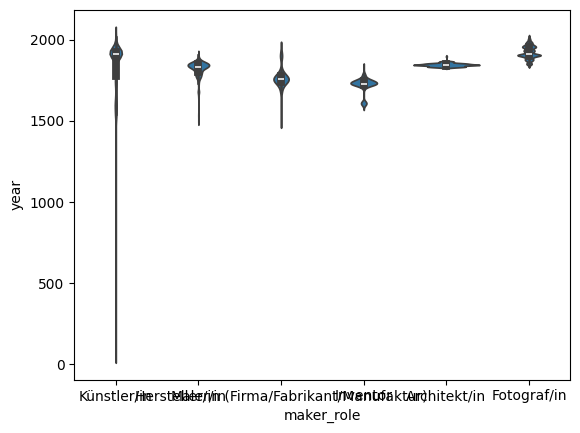

In [11]:
common_maker_roles = plot_df.maker_role.value_counts()
common_maker_roles = common_maker_roles[common_maker_roles > 170].index
plot_df = plot_df[plot_df.maker_role.isin(common_maker_roles)]

sns.violinplot(plot_df, x="maker_role", y="year")

---

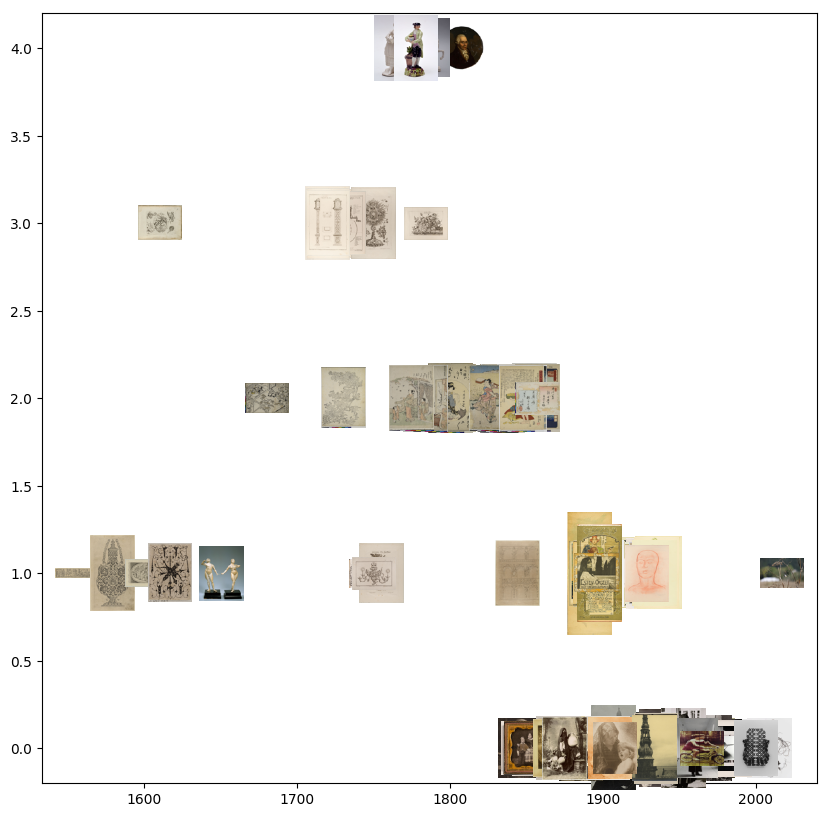

In [55]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

# def get_image(path, zoom=1):
#     path = "./MKG/images/" + path
#     return OffsetImage(plt.imread(path), zoom=zoom)


def my_resize(image):
    fixed_w = 64
    r = image.height/image.width 
    # .thumbnail DOESN'T RETURN ANYTHING
    image.thumbnail((fixed_w, fixed_w*r))#,Image.ANTIALIAS)


def load_image(p, zoom=0.5):
    if not p:
        return Image.new(mode="RGB", size=(512,512))
    path = "./MKG/images/" + p
    img = Image.open(path).convert("RGB")

    my_resize(img)
    return OffsetImage(np.asarray(img), zoom=zoom)


def cat_to_num(c, size=5):
    c = c.fillna("")
    cats = c.value_counts().iloc[:size].index
    trans = dict(zip(cats, range(len(cats))))
    # s = pd.Series(c.apply(lambda x: trans.get(x, len(cats)+1)), index=c)
    return c.apply(lambda x: trans.get(x, -1)), trans #len(cats)+1))



# cat_var = cat_to_num(plot_df.artstyle, size=8)
# cat_var = cat_to_num(plot_df.subcollection_name, size=10)
cat_var, cat_trans = cat_to_num(plot_df.maker_role, size=5)


sub = plot_df[cat_var >= 0].fillna("").sample(300)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(list(sub.year), list(cat_var.loc[sub.index]), ".") 
# ax.plot()

for i, r in sub.iterrows():
    x, y = r.year, cat_var.loc[i]
    # print(r.name, r.title, r.image_path)
    ab = AnnotationBbox(load_image(r.image_path), (x, y), frameon=False)
    ax.add_artist(ab)

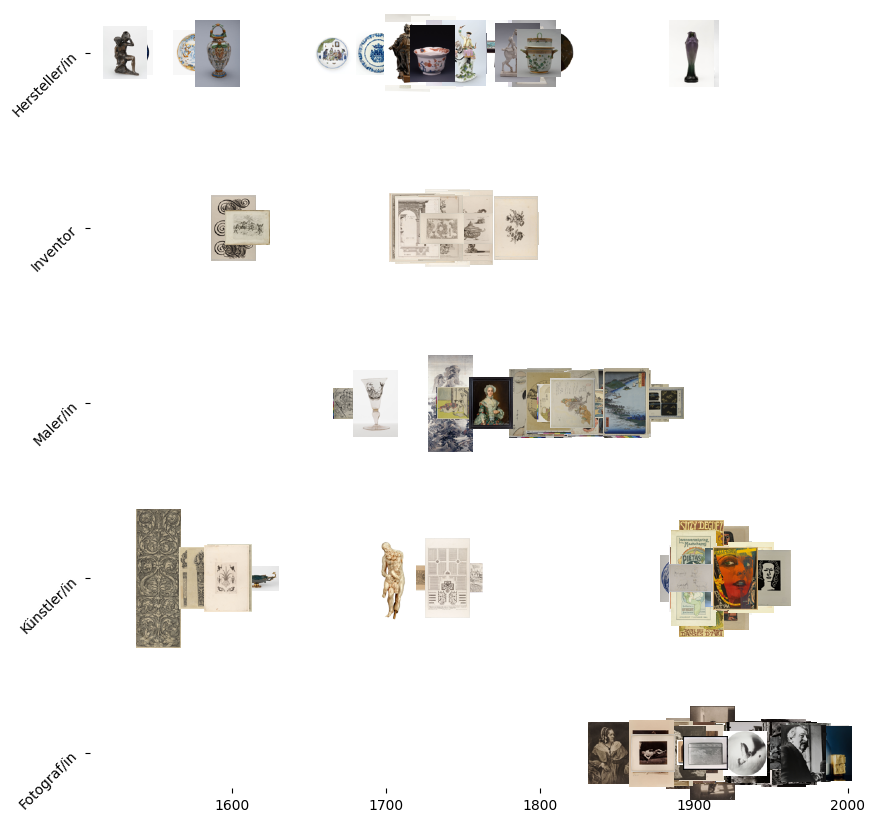

In [78]:
cat_var, cat_trans = cat_to_num(plot_df.maker_role, size=5)

tick_labels, ticks = list(zip(*cat_trans.items()))

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_yticks(ticks, labels=[t[:13] for t in tick_labels], rotation=45)
ax.set_frame_on(False)

k = 50
for cur_cat in cat_var[cat_var >= 0].unique():
    sub = plot_df[cat_var == cur_cat].fillna("").sample(k)
    ax.plot(list(sub.year), [cur_cat]*len(sub), ".")
    for i, r in sub.iterrows():
        x, y = r.year, cat_var.loc[i]
        # print(r.name, r.title, r.image_path)
        ab = AnnotationBbox(load_image(r.image_path), (x, y), frameon=False)
        ax.add_artist(ab)

# ax.plot()

# for i, r in sub.iterrows():
#     x, y = r.year, cat_var.loc[i]
#     # print(r.name, r.title, r.image_path)
#     ab = AnnotationBbox(load_image(r.image_path), (x, y), frameon=False)
#     ax.add_artist(ab)

In [ ]:
...

In [79]:
mkg.sample(1)

,Unnamed: 0,record_id,title,description,subcollection_name,objectname_label,objecttype,material_label,technique_label,artstyle,...,maker_URI,creation_place_URI,coiner_label,coiner_URI,coin_place_label,coin_place_URI,creation_time,coin_time,image_path,sort_rank
object_number,,,,,,,,,,,,,,,,,,,,,
P1976.277.35,22727,DE-MUS-059918/lido/mkg-e00151138,Langkofelgruppe von Norden,Originalseite aus der Publikation: \nDr. Paul ...,Fotografie und neue Medien,NaN,"[Naturfotografie, Landschaftsfotografie, Hessi...",Papier,[Rakeltiefdruck],NaN,...,Großdruckerei Carl Werner,Reichenbach im Vogtland,Großdruckerei Carl Werner,Großdruckerei Carl Werner,Reichenbach im Vogtland,Reichenbach im Vogtland,1948/1942,1948/1942,NaN,21338


In [84]:
mkg.loc[["P2020.84", "1887.166", "1989.59.203"]]

,Unnamed: 0,record_id,title,description,subcollection_name,objectname_label,objecttype,material_label,technique_label,artstyle,...,maker_URI,creation_place_URI,coiner_label,coiner_URI,coin_place_label,coin_place_URI,creation_time,coin_time,image_path,sort_rank
object_number,,,,,,,,,,,,,,,,,,,,,
P2020.84,22091,DE-MUS-059918/lido/mkg-e00199203,"o.T., für Aida Barni","C-Print von 4x5"" Farbdiapositiv",Fotografie und neue Medien,Reprint,[Sachfotografie],C-Print,[Farbpositivverfahren],NaN,...,"Hansen, Hans",Hamburg,"Hansen, Hans","Hansen, Hans",Hamburg,Hamburg,1996,1996,P2020.84.jpg,25675
1887.166,1631,DE-MUS-059918/lido/dc00016052,"Ärmellose Tunika mit Clavi, Purpurwirkerei",Technische Daten:Ungefärbte Leinentunika mit W...,Mode und Textil,NaN,[Gewebe],Schafwolle,"[Broché, gewebt]",NaN,...,NaN,Ägypten,NaN,NaN,Ägypten,Ägypten,0400/0600,0400/0600,1887.166.jpg,1289
1989.59.203,18485,DE-MUS-059918/lido/mkg-e00194973,Färbeschablone (katagami 型紙) mit Pflanzen- und...,Pflanzen- und Vogelmotive in netzartigem Muster.,Ostasien,NaN,[Färber],Japanpapier,"[Fadeneinlage, geschnitten]",Edo-Zeit,...,NaN,Japan,NaN,NaN,Japan,Japan,1801/1900,1801/1900,1989.59.203.jpg,7062


In [85]:
mkg

,Unnamed: 0,record_id,title,description,subcollection_name,objectname_label,objecttype,material_label,technique_label,artstyle,...,maker_URI,creation_place_URI,coiner_label,coiner_URI,coin_place_label,coin_place_URI,creation_time,coin_time,image_path,sort_rank
object_number,,,,,,,,,,,,,,,,,,,,,
1977.193,6092,DE-MUS-059918/lido/dc00126629,NaN,"Formschönes, dünnwandiges Gefäß mit kugeligem ...",Antike,NaN,"[Behälter/Aufbewahrung (Küchenarbeit), Keramik]",Ton,"[handmodelliert, gebrannt (Keramik), bemalt (K...",NaN,...,NaN,Türkei,NaN,NaN,Türkei,Türkei,-5700/-5300,-5700/-5300,1977.193.jpg,1
1967.251,5117,DE-MUS-059918/lido/dc00126455,Kleiner Kopf,NaN,Antike,Terrakotte,"[Kleinplastiken/Kleinkunst, Keramik]",Ton,[handmodelliert],Antike,...,NaN,NaN,NaN,NaN,NaN,NaN,-5000/-3000,-5000/-3000,1967.251.jpg,2
1905.736,20157,DE-MUS-059918/lido/dc00123603,Becher (Black-Topped-Keramik),"Trichterförmiges Gefäß aus rotem Ton, unten mi...",Antike,Black-Topped-Keramik,"[Grabbeigaben, Keramik]",Ton,"[handmodelliert, gebrannt (Keramik), geglättet]",Antike,...,NaN,Ägypten,NaN,NaN,Ägypten,Ägypten,-4000/-3600,-4000/-3600,1905.736.jpg,3
1924.67,23146,DE-MUS-059918/lido/dc00125392,Messer,NaN,Antike,Gerät,[Werkzeuge],Feuerstein,"[retuschiert (Steinbearbeitung), geschlagen]",Antike,...,NaN,Ägypten,NaN,NaN,Ägypten,Ägypten,-4000/-3001,-4000/-3001,1924.67.jpg,4
1919.1,1542,DE-MUS-059918/lido/dc00125085,Schnurösengefäß,"Ovales Gefäß mit Kreismündung und einfacher, o...",Antike,Schnurösengefäß,"[Grabbeigaben, Keramik]",Ton,"[handmodelliert, gebrannt (Keramik), bemalt (K...",Antike,...,NaN,Ägypten,NaN,NaN,Ägypten,Ägypten,-3500/-3200,-3500/-3200,1919.1.jpg,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P2020.129.5,4115,DE-MUS-059918/lido/mkg-e00201487,„Restpflanzen“ aus der Serie „Pechblende/Gesse...,NaN,Fotografie und neue Medien,NaN,[Künstlerische Fotografie],NaN,[Heliogravüre],NaN,...,"Kriemann, Susanne",Berlin,"Kriemann, Susanne","Kriemann, Susanne",Berlin,Berlin,2017/2020,2017/2020,P2020.129.5.jpg,26290
P2020.130.1,4114,DE-MUS-059918/lido/mkg-e00201488,Aus der Serie „Mngrv“,NaN,Fotografie und neue Medien,NaN,[Künstlerische Fotografie],NaN,[Inkjetdruck],NaN,...,"Kriemann, Susanne",NaN,"Kriemann, Susanne","Kriemann, Susanne",NaN,NaN,2018/2020,2018/2020,P2020.130.1.jpg,26291
P2020.130.2,4113,DE-MUS-059918/lido/mkg-e00201489,Aus der Serie „Mngrv“,NaN,Fotografie und neue Medien,NaN,[Künstlerische Fotografie],NaN,[Inkjetdruck],NaN,...,"Kriemann, Susanne",NaN,"Kriemann, Susanne","Kriemann, Susanne",NaN,NaN,2018/2020,2018/2020,P2020.130.2.jpg,26292


In [95]:
mkg.coll.filter("ringelnatz")

,Unnamed: 0,record_id,title,description,subcollection_name,objectname_label,objecttype,material_label,technique_label,artstyle,...,maker_URI,creation_place_URI,coiner_label,coiner_URI,coin_place_label,coin_place_URI,creation_time,coin_time,image_path,sort_rank
object_number,,,,,,,,,,,,,,,,,,,,,


In [99]:
mkg.img_url.iloc[1000]

'http://digicult-web.digicult-verbund.de/entity-resources/images/digicult-web-mkg/1/1989.544+1.jpg'

In [ ]:
http://digicult-web.digicult-verbund.de/entity-resources/images/digicult-web-mkg/1/